## DisasterSenseAI - BERT Fine-Tuning

### Objective

Fine-tune **bert-base-uncased** on the Kaggle **Natural Language Processing with Disaster Tweets** dataset.

Tasks:

- Load and preprocess the dataset
- Tokenize all tweets
- Fine-tune BERT using PyTorch and Hugging Face Transformers
- Evaluate the model on the validation set
- Compare performance with the Logistic Regression baseline
- Save the trained model for deployment in Streamlit

In [1]:
from tqdm.auto import tqdm

In [2]:
!pip -q install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [3]:

import random
import numpy as np
import pandas as pd
import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
print(f"PyTorch Version : {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

# Display GPU Information

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected.")


PyTorch Version : 2.11.0+cu128
Device : cuda
GPU : Tesla T4


In [5]:
# Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
# Load Dataset

train_df = pd.read_csv("train.csv")

print(f"Dataset Shape : {train_df.shape}")

# Preview the dataset

train_df.head()

Dataset Shape : (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
# Dataset Information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [8]:
# Keep only the columns required for BERT

bert_df = train_df[["text", "target"]].copy()

bert_df.head()


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [9]:
# Check for missing values

bert_df.isnull().sum()

,0
text,0
target,0


In [10]:
# Set Random Seed


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed Set To : {SEED}")

Random Seed Set To : 42


In [11]:
# Split Dataset

train_texts, val_texts, train_labels, val_labels = train_test_split(
    bert_df["text"],
    bert_df["target"],
    test_size=0.2,
    random_state=SEED,
    stratify=bert_df["target"]
)

# Display Split Sizes

print(f"Training Samples  : {len(train_texts)}")
print(f"Validation Samples: {len(val_texts)}")

Training Samples  : 6090
Validation Samples: 1523


In [12]:
# Display label distribution

print("Training Label Distribution")
print(train_labels.value_counts())

print("\nValidation Label Distribution")
print(val_labels.value_counts())

Training Label Distribution
target
0    3473
1    2617
Name: count, dtype: int64

Validation Label Distribution
target
0    869
1    654
Name: count, dtype: int64


In [13]:
train_preview = pd.DataFrame({
    "Tweet": train_texts.head().values,
    "Label": train_labels.head().values
})

train_preview

,Tweet,Label
0,Sassy city girl country hunk stranded in Smoky...,1
1,God's Kingdom (Heavenly Gov't) will rule over ...,0
2,Mopheme and Bigstar Johnson are a problem in t...,0
3,@VixMeldrew sounds like a whirlwind life!,0
4,Malaysia confirms plane debris washed up on Re...,1


In [14]:
# Load BERT Tokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
# Tokenize Training Tweets

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)

In [16]:
# Tokenize Validation Tweets

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)

In [17]:
# Inspect tokenizer output

train_encodings.keys()

KeysView({'input_ids': [[101, 21871, 6508, 2103, 2611, 2406, 15876, 8950, 15577, 1999, 20629, 3137, 4586, 19718, 1001, 20118, 5244, 8299, 1024, 1013, 1013, 1056, 1012, 2522, 1013, 25930, 2243, 6593, 4779, 16150, 2683, 1001, 21307, 14659, 14301, 2063, 1001, 2338, 5092, 14122, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2643, 1005, 1055, 2983, 1006, 16581, 18079, 1005, 1056, 1007, 2097, 3627, 2058, 2035, 2111, 2006, 1996, 3011, 2044, 2849, 18655, 5280, 1012, 8299, 1024, 1013, 1013, 1056, 1012, 2522, 1013, 1022, 25619, 27421, 2595, 6968, 2480, 2692, 8299, 1024, 1013, 1013, 1056, 1012, 2522, 1013, 1018, 3683, 2361, 2243, 5666, 2615, 4779, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [18]:
# Number of tokenized training samples

len(train_encodings["input_ids"])

6090

In [19]:
# Shape of one encoded tweet

len(train_encodings["input_ids"][0])

128

## Create a Custom PyTorch Dataset

### Objective

Convert the tokenized tweets into a PyTorch Dataset.

A Dataset acts as a bridge between our preprocessed data and the training loop.

The Dataset will return one training example at a time, consisting of:

- input_ids
- attention_mask
- label

The DataLoader will later use this Dataset to create mini-batches for BERT training.

In [20]:
# Custom Dataset for BERT

from torch.utils.data import Dataset


class DisasterTweetDataset(Dataset):

    def __init__(self, encodings, labels):
        """
        Store tokenized tweets and corresponding labels.
        """
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return one training example.
        """

        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

In [21]:
# Create Training and Validation Datasets


train_dataset = DisasterTweetDataset(
    train_encodings,
    train_labels
)

val_dataset = DisasterTweetDataset(
    val_encodings,
    val_labels
)

len(train_dataset)

6090

In [22]:
train_dataset[0]

{'input_ids': tensor([  101, 21871,  6508,  2103,  2611,  2406, 15876,  8950, 15577,  1999,
         20629,  3137,  4586, 19718,  1001, 20118,  5244,  8299,  1024,  1013,
          1013,  1056,  1012,  2522,  1013, 25930,  2243,  6593,  4779, 16150,
          2683,  1001, 21307, 14659, 14301,  2063,  1001,  2338,  5092, 14122,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

## Create DataLoaders

### Objective

Create PyTorch DataLoaders for the training and validation datasets.

A DataLoader loads the Dataset in small batches instead of sending the entire dataset to the model at once.

This makes training efficient and enables mini-batch gradient descent.

In [23]:

# Import DataLoader

from torch.utils.data import DataLoader

# Hyperparameters

BATCH_SIZE = 16

In [24]:
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Create validation DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Number of training batches

len(train_loader)

381

In [25]:
# Get the first training batch

batch = next(iter(train_loader))

batch.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [26]:
# Display tensor shapes

for key, value in batch.items():
    print(f"{key:<15} {value.shape}")

input_ids       torch.Size([16, 128])
token_type_ids  torch.Size([16, 128])
attention_mask  torch.Size([16, 128])
labels          torch.Size([16])


## Load the Pretrained BERT Model

### Objective

Load the pretrained **BERT Base** model and configure it for binary tweet classification.

The pretrained weights provide language understanding, while the classification layer will be fine-tuned for the Disaster Tweets dataset.

In [27]:
# Load pretrained BERT model

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
# Move model to GPU

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [29]:
# Display model device

print(next(model.parameters()).device)

cuda:0


## Configure Training

### Objective

Define the optimizer and training hyperparameters.

These settings control how BERT learns during fine-tuning.

In [30]:
# Import optimizer

from torch.optim import AdamW

In [32]:
# Define training hyperparameters

LEARNING_RATE = 2e-5 #0.00002
EPOCHS = 3
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Epochs       : {EPOCHS}")

Learning Rate : 2e-05
Epochs       : 3


In [33]:
# Create optimizer

from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 2e-05
    lr: 2e-05
    maximize: False
    weight_decay: 0.01
)


## Fine-Tune BERT

### Objective

Train the pretrained BERT model on the Disaster Tweets dataset.

During each training batch, the model will:

1. Perform a forward pass
2. Compute the classification loss
3. Calculate gradients using backpropagation
4. Update model weights using the AdamW optimizer

This process is repeated for multiple epochs until the model learns to classify disaster tweets accurately.

In [34]:
# Set model to training mode

best_val_accuracy = 0.0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    model.train()

    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):

        # Move batch to GPU
        batch = {key: value.to(device) for key, value in batch.items()}

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(**batch)

        # Compute loss
        loss = outputs.loss

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Update learning rate
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Average Training Loss: {avg_loss:.4f}")


Epoch 1/3


Epoch 1/3:   0%|          | 0/381 [00:00<?, ?it/s]

Average Training Loss: 0.4344

Epoch 2/3


Epoch 2/3:   0%|          | 0/381 [00:00<?, ?it/s]

Average Training Loss: 0.3003

Epoch 3/3


Epoch 3/3:   0%|          | 0/381 [00:00<?, ?it/s]

Average Training Loss: 0.2158


In [35]:
# Import evaluation utilities

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Set model to evaluation mode

model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [36]:
# Store predictions and true labels

predictions = []
true_labels = []

In [37]:
# Disable gradient computation

with torch.no_grad():

    for batch in tqdm(val_loader, desc="Evaluating"):

        # Move batch to GPU
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        # Forward pass
        outputs = model(**batch)

        # Get predicted class
        preds = torch.argmax(outputs.logits, dim=1)

        # Store predictions
        predictions.extend(preds.cpu().numpy())

        # Store true labels
        true_labels.extend(batch["labels"].cpu().numpy())

Evaluating:   0%|          | 0/96 [00:00<?, ?it/s]

In [38]:
# Calculate accuracy

accuracy = accuracy_score(true_labels, predictions)

print(f"Validation Accuracy: {accuracy:.4f}")

# Display classification report

print("\n Classification Report: \n")

print(classification_report(true_labels, predictions))


Validation Accuracy: 0.8404

 Classification Report: 

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       869
           1       0.82      0.81      0.81       654

    accuracy                           0.84      1523
   macro avg       0.84      0.84      0.84      1523
weighted avg       0.84      0.84      0.84      1523



In [39]:
# Generate confusion matrix

cm = confusion_matrix(true_labels, predictions)

print(cm)

[[752 117]
 [126 528]]


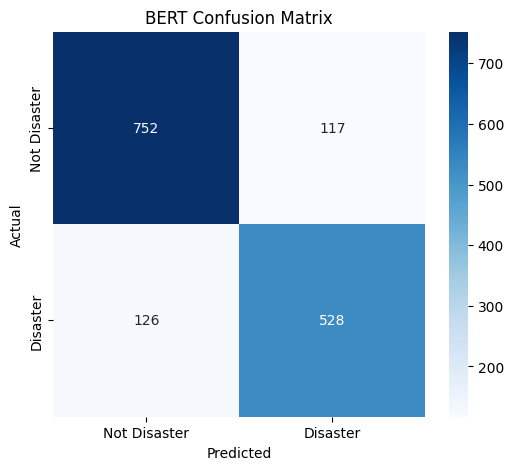

In [40]:
# Plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Disaster", "Disaster"],
    yticklabels=["Not Disaster", "Disaster"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")

plt.show()

In [41]:
# Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [42]:
# Folder to save the trained model

SAVE_PATH = "/content/drive/MyDrive/DisasterSenseAI/models/bert_model"

# Save BERT model

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/DisasterSenseAI/models/bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/DisasterSenseAI/models/bert_model/tokenizer.json')

In [43]:
import os

os.listdir(SAVE_PATH)

['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']